In [1]:
pip install hmmlearn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
df=pd.read_csv("makerere_kiosk_synthetic.csv")
df.head()

,Transaction_ID,Date,Time,Hour,Day_of_Week,Academic_Period,Is_Weekend,Near_Lecture_Start,Kiosk_ID,Kiosk_Name,Kiosk_Location,Item,Quantity,Unit_Price_UGX,Total_Amount_UGX,Payment_Method,Price_vs_Base_Pct
0,TXN000001,2024-02-01,07:01,7,Thursday,Sem1_Teaching,False,False,K04,Education Block Kiosk,Education,Juice (Splash),1,"1,650","1,650",Cash,10.0
1,TXN000002,2024-02-01,07:02,7,Thursday,Sem1_Teaching,False,False,K05,Senate Building Kiosk,Senate Building,Biscuits (Packet),1,"1,000","1,000",Cash,0.0
2,TXN000003,2024-02-01,07:08,7,Thursday,Sem1_Teaching,False,False,K04,Education Block Kiosk,Education,Chapati,1,"1,000","1,000",Airtel Money,0.0
3,TXN000004,2024-02-01,07:09,7,Thursday,Sem1_Teaching,False,False,K01,Freedom Square Kiosk,Freedom Square,Water Bottle,1,500,500,Cash,-50.0
4,TXN000005,2024-02-01,07:11,7,Thursday,Sem1_Teaching,False,False,K03,Engineering Block Kiosk,Engineering,Mandazi (2 pcs),1,250,250,Cash,0.0


In [5]:
features=df[['Hour','Quantity','Total_Amount_UGX']]

In [8]:
# Remove commas and convert to numeric
features['Total_Amount_UGX'] = features['Total_Amount_UGX'].replace(',', '', regex=True).astype(float)

features.head()

C:\Users\USER\AppData\Local\Temp\ipykernel_21528\702635724.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features['Total_Amount_UGX'] = features['Total_Amount_UGX'].replace(',', '', regex=True).astype(float)


,Hour,Quantity,Total_Amount_UGX
0,7,1,1650.0
1,7,1,1000.0
2,7,1,1000.0
3,7,1,500.0
4,7,1,250.0


In [9]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x = scaler.fit_transform(features)

In [13]:
features=features.replace({',':''}, regex=True)
features=features.apply(pd.to_numeric,errors='coerce')
features=features.dropna()

In [12]:
from hmmlearn import hmm
model = hmm.GaussianHMM(
    n_components=2,  
    covariance_type='diag',  
    n_iter=200,  
    
)
model.fit(x)

GaussianHMM(n_components=2, n_iter=200)

In [14]:
#predict the hidden states
hidden_states = model.predict(x)
df['Demand_State'] = hidden_states
df.head()

,Transaction_ID,Date,Time,Hour,Day_of_Week,Academic_Period,Is_Weekend,Near_Lecture_Start,Kiosk_ID,Kiosk_Name,Kiosk_Location,Item,Quantity,Unit_Price_UGX,Total_Amount_UGX,Payment_Method,Price_vs_Base_Pct,Demand_State
0,TXN000001,2024-02-01,07:01,7,Thursday,Sem1_Teaching,False,False,K04,Education Block Kiosk,Education,Juice (Splash),1,"1,650","1,650",Cash,10.0,0
1,TXN000002,2024-02-01,07:02,7,Thursday,Sem1_Teaching,False,False,K05,Senate Building Kiosk,Senate Building,Biscuits (Packet),1,"1,000","1,000",Cash,0.0,0
2,TXN000003,2024-02-01,07:08,7,Thursday,Sem1_Teaching,False,False,K04,Education Block Kiosk,Education,Chapati,1,"1,000","1,000",Airtel Money,0.0,0
3,TXN000004,2024-02-01,07:09,7,Thursday,Sem1_Teaching,False,False,K01,Freedom Square Kiosk,Freedom Square,Water Bottle,1,500,500,Cash,-50.0,0
4,TXN000005,2024-02-01,07:11,7,Thursday,Sem1_Teaching,False,False,K03,Engineering Block Kiosk,Engineering,Mandazi (2 pcs),1,250,250,Cash,0.0,0


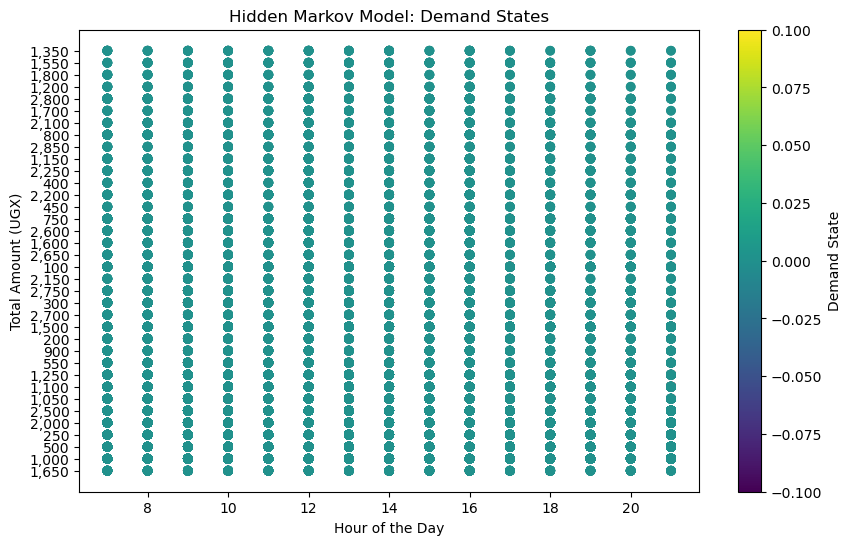

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(df['Hour'], df['Total_Amount_UGX'], c=df['Demand_State'],cmap='viridis')
plt.xlabel('Hour of the Day')
plt.ylabel('Total Amount (UGX)')
plt.title('Hidden Markov Model: Demand States')
plt.colorbar(label="Demand State")
plt.show()

In [ ]:
df[]